In [1]:
# Load libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import MonthLocator
import matplotlib.ticker as mtick
import os
import json
import sys
import datetime
from datetime import date
from matplotlib.dates import MO, WeekdayLocator, MonthLocator, YearLocator
from datetime import datetime, UTC, date
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter, MO
from IPython.display import HTML

plots_filepath = 'plots/july-25/'

# Append utils to path for logo import
sys.path.append("utils")
from logo import add_logo

def format_date_with_suffix(date_obj):
    # 1) turn str or datetime/date into a pd.Timestamp
    ts = pd.to_datetime(date_obj)

    # 2) get the day and compute the ordinal suffix
    day = ts.day
    if 10 <= day % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(day % 10, 'th')

    # 3) build the final string
    #    Month name: ts.strftime('%B')
    #    Day + suffix: f'{day}{suffix}'
    #    Year: ts.year
    return f"{ts.strftime('%B')} {day}{suffix}, {ts.year}"


today = datetime.today()
date = format_date_with_suffix(today)

In [2]:
# Function for plotting revenue or fees / mcap or fdv charts for a set of assets

def revenue_vs_fdv_asset(start_date, assets, breakout_asset, bottom_metric, top_metric, category_title):
    df_master = None
    # Load revenue and FDV data
    for asset_slug, asset_name in assets.items():
        rev_path = f"raw-data/defillama-raw-data/daily{bottom_metric}_data/{asset_slug}_{bottom_metric}.json"
        with open(rev_path) as rev_f:
            rev_data = json.load(rev_f)
    
        rev_df = pd.DataFrame(rev_data["totalDataChart"], columns=["timestamp", f"{asset_slug}-{bottom_metric}"])
        rev_df["date"] = pd.to_datetime(rev_df["timestamp"], unit="s")
        rev_df[f"{asset_slug}-annualized-{bottom_metric}"] = rev_df[f"{asset_slug}-{bottom_metric}"] * 365
        rev_df = rev_df[["date", f"{asset_slug}-annualized-{bottom_metric}"]]

        # Load fdv data
        fdv_path = f'raw-data/messari-raw-data/messari_{asset_slug}_marketcap.json'
        with open(fdv_path) as fdv_f:
            fdv_data = json.load(fdv_f)
        
        points = fdv_data['data']['points']
        fdv_df = pd.DataFrame(points, columns=[
            'timestamp',
            'circulating-marketcap',
            'circulating-marketcap-dominance',
            'fully-diluted-marketcap'
        ])
        fdv_df["date"] = pd.to_datetime(fdv_df["timestamp"], unit="s")
        if top_metric == 'FDV':
            fdv_df = fdv_df[['date','fully-diluted-marketcap']]
            fdv_df.rename(columns={'fully-diluted-marketcap': f'{asset_slug}-{top_metric}'}, inplace=True)

        if top_metric == 'MCAP':
            fdv_df = fdv_df[['date','circulating-marketcap']]
            fdv_df.rename(columns={'circulating-marketcap': f'{asset_slug}-{top_metric}'}, inplace=True)
        
        # Merge datasets for a given asset
        interim_df = pd.merge(rev_df, fdv_df, on="date", how="outer")

        # Fill blanks
        interim_df = interim_df.ffill()
        
        # Calculate multiple
        interim_df[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple'] = interim_df[f'{asset_slug}-{top_metric}'] / interim_df[f'{asset_slug}-annualized-{bottom_metric}']
        interim_df[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple-7d'] = interim_df[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple'].rolling(window=7, min_periods=1).mean()
        
        # Merge asset dataframe into the master dataframe
        df_master = interim_df if df_master is None else df_master.merge(interim_df, on="date", how="outer")
        df_master = df_master.sort_values("date").reset_index(drop=True)

    # Cut off df_master to only be after start date
    df_master = df_master[df_master['date'] >= start_date]
    
    # define which asset to exclude
    if breakout_asset is None:
        # only include the others
        fdv_cols = [
            f"{slug}-{top_metric}"
            for slug in assets
        ]
        mult_cols = [
            f"{slug}-{top_metric}-to-annualized-{bottom_metric}-multiple"
            for slug in assets
        ]  
        
    else:
        exclude = breakout_asset[0]
        
            # only include the others
        fdv_cols = [
            f"{slug}-{top_metric}"
            for slug in assets
            if slug != exclude
        ]
        mult_cols = [
            f"{slug}-{top_metric}-to-annualized-{bottom_metric}-multiple"
            for slug in assets
            if slug != exclude
        ]
    
    # per-row FDV denominator
    fdv_den = df_master[fdv_cols].sum(axis=1)
    
    # row-wise weights for each FDV column
    weights = df_master[fdv_cols].div(fdv_den, axis=0)
    
    # compute each asset’s weighted term
    weighted_terms = []
    for fdv_col, mult_col in zip(fdv_cols, mult_cols):
        term = weights[fdv_col] * df_master[mult_col]
        weighted_terms.append(term)
    
    # sum them to get your per-day FDV-weighted average
    df_master[f'{top_metric}_weighted_avg_multiple'] = sum(weighted_terms)

    df_master[f'{top_metric}_weighted_avg_multiple-7d'] = df_master[f'{top_metric}_weighted_avg_multiple'].rolling(window=7, min_periods=1).mean()
    
    # Create the line chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plotting the line chart with custom colors
    for asset_slug, asset_name in assets.items():
        ax.plot(
            df_master['date'], 
            df_master[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple-7d'], 
            label=asset_name, 
            linewidth=2
        )
    
    # Setting labels and title
    ax.set_title(f'{category_title}: {top_metric} / Annualized {bottom_metric}')
    ax.margins(x=0)
    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}x'))

    # Add grid lines for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add logo
    add_logo(ax, position=(0.075, -0.18))
    
    # Add sources and note
    text_box = ax.text(0, -0.27, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama and Messari.",
                       ha='left', transform=ax.transAxes, fontsize=10,
                       bbox=dict(facecolor='white', alpha=0), fontstyle='italic')
    
    # Center the legend below the chart
    plt.legend(title=f'Select {category_title}', bbox_to_anchor=(0.85, -0.13), loc='upper center', ncol=2)
    
    # Ensure the layout adapts to fit all elements (legend, text, etc.)
    plt.tight_layout()
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}select {category_title} annualized {bottom_metric} multiples.png", dpi=300, bbox_inches='tight')
    
    # Show
    plt.show()

    if breakout_asset is None:
        # Calculate statistical percentiles for multiple
        median_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].median(), 0)
        latest_cohort_multiple = round(df_master[f'{top_metric}_weighted_avg_multiple'].dropna().iloc[-1],0)
        mean_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].mean(), 0)
        percentile_80_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.80),0)
        percentile_20_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.20),0)
        stdev_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].std(),0)
    
        stats_cohort = {
            "median_multiple": median_cohort,
            'latest_multiple': latest_cohort_multiple,
            'mean_multiple': mean_cohort,
            "80th_percentile_multiple": percentile_80_cohort,
            "20th_percentile_multiple": percentile_20_cohort,
            'stdev_multiple': stdev_cohort
        }
    
        # Print results in human-readable format
        print()
        print(f"{category_title} {top_metric} / Annualized {bottom_metric} Statistics:")
        print(f"Median {top_metric} / Annualized {bottom_metric}: {median_cohort:,.0f}x")
        print(f"Latest Multiple: {latest_cohort_multiple:,.0f}x")
        print(f"Mean {top_metric} / Annualized {bottom_metric}: {mean_cohort:,.0f}x")
        print(f"80th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_80_cohort:,.0f}x")
        print(f"20th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_20_cohort:,.0f}x")
        print(f'Standard Deviation: {stdev_cohort:,.0f}x')
        print()
    
        return stats_cohort

    else:
        # Calculate statistical percentiles for multiple
        median_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].median(), 0)
        latest_cohort_multiple = round(df_master[f'{top_metric}_weighted_avg_multiple'].dropna().iloc[-1],0)
        mean_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].mean(), 0)
        percentile_80_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.80),0)
        percentile_20_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.20),0)
        stdev_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].std(),0)
        
        median_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].median(), 0)
        latest_breakout_multiple = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].dropna().iloc[-1],0)
        mean_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].mean(), 0)
        percentile_80_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].quantile(0.80),0)
        percentile_20_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].quantile(0.20),0)
        stdev_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].std(),0)
    
        stats_cohort = {
            "median_multiple": median_cohort,
            'latest_multiple': latest_cohort_multiple,
            'mean_multiple': mean_cohort,
            "80th_percentile_multiple": percentile_80_cohort,
            "20th_percentile_multiple": percentile_20_cohort,
            'stdev_multiple': stdev_cohort
        }
    
        stats_breakout = {
            "median_multiple": median_breakout,
            'latest_multiple': latest_breakout_multiple,
            'mean_multiple': mean_breakout,
            "80th_percentile_multiple": percentile_80_breakout,
            "20th_percentile_multiple": percentile_20_breakout,
            'stdev_multiple': stdev_breakout
        }
        
        # Print results in human-readable format
        print()
        print(f"{category_title} {top_metric} / Annualized {bottom_metric} Statistics (Excluding {breakout_asset[1]}):")
        print(f"Median {top_metric} / Annualized {bottom_metric}: {median_cohort:,.0f}x")
        print(f"Latest Multiple: {latest_cohort_multiple:,.0f}x")
        print(f"Mean {top_metric} / Annualized {bottom_metric}: {mean_cohort:,.0f}x")
        print(f"80th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_80_cohort:,.0f}x")
        print(f"20th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_20_cohort:,.0f}x")
        print(f'Standard Deviation: {stdev_cohort:,.0f}x')
        print()
        
        print(f"{breakout_asset[1]} {top_metric} / Annualized {bottom_metric} Statistics:")
        print(f"Median {top_metric} / Annualized {bottom_metric}: {median_breakout:,.0f}x")
        print(f"Latest Multiple: {latest_breakout_multiple:,.0f}x")
        print(f"Mean {top_metric} / Annualized {bottom_metric}: {mean_breakout:,.0f}x")
        print(f"80th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_80_breakout:,.0f}x")
        print(f"20th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_20_breakout:,.0f}x")
        print(f'Standard Deviation: {stdev_breakout:,.0f}x')
        print()
    
        return stats_cohort, stats_breakout

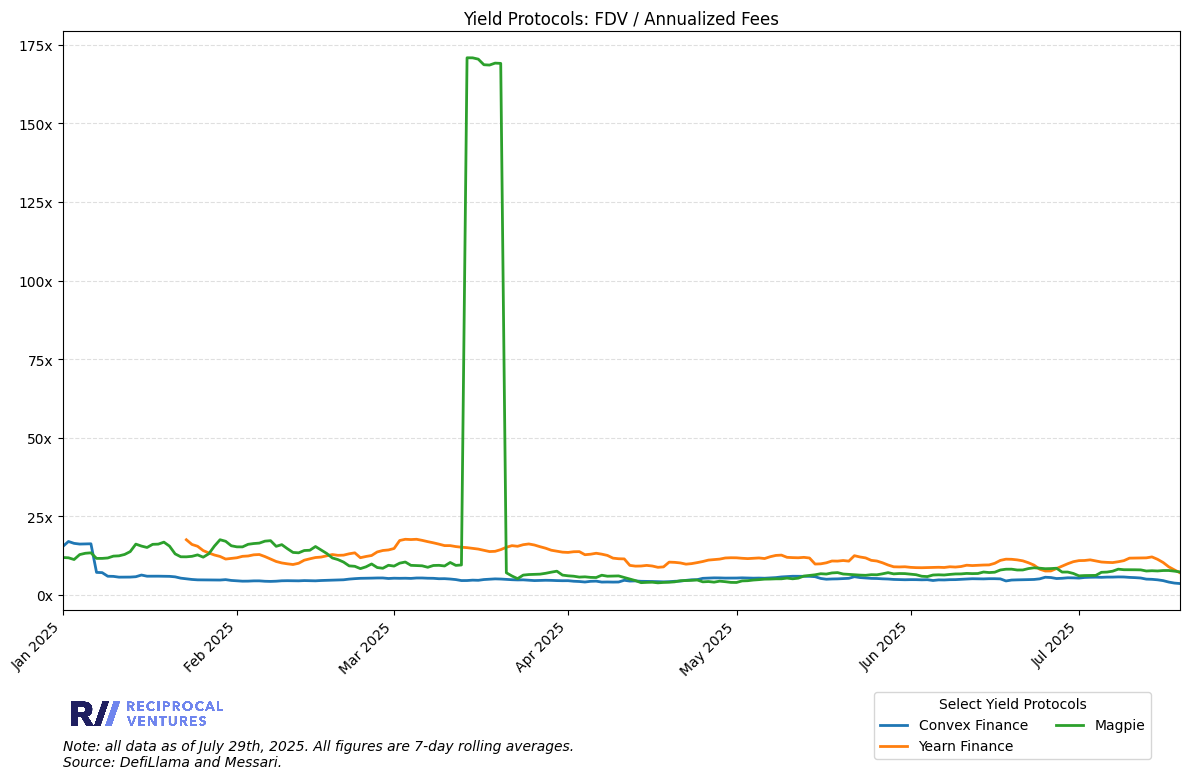


Yield Protocols FDV / Annualized Fees Statistics:
Median FDV / Annualized Fees: 8x
Latest Multiple: 3x
Mean FDV / Annualized Fees: 9x
80th Percentile FDV / Annualized Fees: 10x
20th Percentile FDV / Annualized Fees: 7x
Standard Deviation: 8x



In [3]:
# Call the function for perp dexs
yield_protocols = {
    'convex-finance': 'Convex Finance',
    'yearn-finance': 'Yearn Finance',
    'magpie-ecosystem': 'Magpie',
}


# 'bottom_metric' should be 'Fees' or 'Revenue'; 'top_metric' should be 'FDV' or 'MCAP'
start_date = '2025-01-01'
assets = yield_protocols
breakout_asset = None
bottom_metric = 'Fees'
top_metric = 'FDV'
category_title = 'Yield Protocols'

fee_yield_stats = revenue_vs_fdv_asset(
    start_date     = start_date,
    assets         = assets,
    breakout_asset = breakout_asset,
    bottom_metric  = bottom_metric,
    top_metric     = top_metric,
    category_title = category_title
)

In [4]:
# Function for plotting tvl / mcap or fdv charts for a set of assets

def tvl_vs_fdv_asset(start_date, assets, breakout_asset, top_metric, category_title):
    df_master = None
    # Loadtvl and FDV data
    for asset_slug, asset_name in assets.items():
        tvl_path = f"raw-data/defillama-raw-data/tvl_data/{asset_slug}_tvl.json"
        with open(tvl_path) as tvl_f:
            tvl_data = json.load(tvl_f)

        tvl_df = pd.DataFrame(
            tvl_data['tvl'],
            columns=['date', 'totalLiquidityUSD']
        )
        tvl_df.rename(columns={
            'date': 'timestamp',
            'totalLiquidityUSD': f'{asset_slug}-TVL'
        }, inplace=True)
        tvl_df['date'] = pd.to_datetime(tvl_df['timestamp'], unit='s')
        tvl_df = tvl_df[['date', f'{asset_slug}-TVL']]

        # Load fdv data
        fdv_path = f'raw-data/messari-raw-data/messari_{asset_slug}_marketcap.json'
        with open(fdv_path) as fdv_f:
            fdv_data = json.load(fdv_f)
        
        points = fdv_data['data']['points']
        fdv_df = pd.DataFrame(points, columns=[
            'timestamp',
            'circulating-marketcap',
            'circulating-marketcap-dominance',
            'fully-diluted-marketcap'
        ])
        fdv_df["date"] = pd.to_datetime(fdv_df["timestamp"], unit="s")
        if top_metric == 'FDV':
            fdv_df = fdv_df[['date','fully-diluted-marketcap']]
            fdv_df.rename(columns={'fully-diluted-marketcap': f'{asset_slug}-{top_metric}'}, inplace=True)

        if top_metric == 'MCAP':
            fdv_df = fdv_df[['date','circulating-marketcap']]
            fdv_df.rename(columns={'circulating-marketcap': f'{asset_slug}-{top_metric}'}, inplace=True)
        
        # Merge datasets for a given asset
        interim_df = pd.merge(tvl_df, fdv_df, on="date", how="outer")

        # Fill blanks
        interim_df = interim_df.ffill()
        
        # Calculate multiple
        interim_df[f'{asset_slug}-{top_metric}-to-TVL-multiple'] = interim_df[f'{asset_slug}-{top_metric}'] / interim_df[f'{asset_slug}-TVL']
        interim_df[f'{asset_slug}-{top_metric}-to-TVL-multiple-7d'] = interim_df[f'{asset_slug}-{top_metric}-to-TVL-multiple'].rolling(window=7, min_periods=1).mean()
        
        # Merge asset dataframe into the master dataframe
        df_master = interim_df if df_master is None else df_master.merge(interim_df, on="date", how="outer")
        df_master = df_master.sort_values("date").reset_index(drop=True)

    # Cut off df_master to only be after start date
    df_master = df_master[df_master['date'] >= start_date]
    
    # define which asset to exclude
    if breakout_asset is None:
        # only include the others
        fdv_cols = [
            f"{slug}-{top_metric}"
            for slug in assets
        ]
        mult_cols = [
            f"{slug}-{top_metric}-to-TVL-multiple"
            for slug in assets
        ]    
        
    else:
        exclude = breakout_asset[0]
        
        # only include the others
        fdv_cols = [
            f"{slug}-{top_metric}"
            for slug in assets
            if slug != exclude
        ]
        mult_cols = [
            f"{slug}-{top_metric}-to-TVL-multiple"
            for slug in assets
            if slug != exclude
        ]
    
    # per-row FDV denominator
    fdv_den = df_master[fdv_cols].sum(axis=1)
    
    # row-wise weights for each FDV column
    weights = df_master[fdv_cols].div(fdv_den, axis=0)
    
    # compute each asset’s weighted term
    weighted_terms = []
    for fdv_col, mult_col in zip(fdv_cols, mult_cols):
        term = weights[fdv_col] * df_master[mult_col]
        weighted_terms.append(term)
    
    # sum them to get your per-day FDV-weighted average
    df_master[f'{top_metric}_weighted_avg_multiple'] = sum(weighted_terms)

    df_master[f'{top_metric}_weighted_avg_multiple-7d'] = df_master[f'{top_metric}_weighted_avg_multiple'].rolling(window=7, min_periods=1).mean()
    
    # Create the line chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plotting the line chart with custom colors
    for asset_slug, asset_name in assets.items():
        ax.plot(
            df_master['date'], 
            df_master[f'{asset_slug}-{top_metric}-to-TVL-multiple-7d'], 
            label=asset_name, 
            linewidth=2
        )
    
    # Setting labels and title
    ax.set_title(f'{category_title}: {top_metric} / TVL')
    ax.margins(x=0)
    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.1f}x'))

    # Add grid lines for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add logo
    add_logo(ax, position=(0.075, -0.18))
    
    # Add sources and note
    text_box = ax.text(0, -0.27, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama and Messari.",
                       ha='left', transform=ax.transAxes, fontsize=10,
                       bbox=dict(facecolor='white', alpha=0), fontstyle='italic')
    
    # Center the legend below the chart
    plt.legend(title=f'Select {category_title}', bbox_to_anchor=(0.85, -0.13), loc='upper center', ncol=2)
    
    # Ensure the layout adapts to fit all elements (legend, text, etc.)
    plt.tight_layout()
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}select {category_title} TVL multiples.png", dpi=300, bbox_inches='tight')
    
    # Show
    plt.show()

    if breakout_asset is None:
        # Calculate statistical percentiles for multiple
        median_cohort = df_master[f'{top_metric}_weighted_avg_multiple'].median()
        latest_cohort_multiple = df_master[f'{top_metric}_weighted_avg_multiple'].dropna().iloc[-1]
        mean_cohort = df_master[f'{top_metric}_weighted_avg_multiple'].mean()
        percentile_80_cohort = df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.80)
        percentile_20_cohort = df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.20)
        stdev_cohort = df_master[f'{top_metric}_weighted_avg_multiple'].std()
        
    
        stats_cohort = {
            "median_multiple": median_cohort,
            'latest_multiple': latest_cohort_multiple,
            'mean_multiple': mean_cohort,
            "80th_percentile_multiple": percentile_80_cohort,
            "20th_percentile_multiple": percentile_20_cohort,
            'stdev_multiple': stdev_cohort
        }
        
        # Print results in human-readable format
        print(f"{category_title} {top_metric} / TVL Statistics:")
        print(f"Median {top_metric} / TVL: {median_cohort:,.1f}x")
        print(f"Latest Multiple: {latest_cohort_multiple:,.1f}x")
        print(f"Mean {top_metric} / TVL: {mean_cohort:,.1f}x")
        print(f"80th Percentile {top_metric} / TVL: {percentile_80_cohort:,.1f}x")
        print(f"20th Percentile {top_metric} / TVL: {percentile_20_cohort:,.1f}x")
        print(f'Standard Deviation: {stdev_cohort:,.1f}x')
        print()
    
        return stats_cohort
    
    else:
        # Calculate statistical percentiles for multiple
        median_cohort = df_master[f'{top_metric}_weighted_avg_multiple'].median()
        latest_cohort_multiple = df_master[f'{top_metric}_weighted_avg_multiple'].dropna().iloc[-1]
        mean_cohort = df_master[f'{top_metric}_weighted_avg_multiple'].mean()
        percentile_80_cohort = df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.80)
        percentile_20_cohort = df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.20)
        stdev_cohort = df_master[f'{top_metric}_weighted_avg_multiple'].std()
        
        median_breakout = df_master[f'{breakout_asset[0]}-{top_metric}-to-TVL-multiple'].median()
        latest_breakout_multiple = df_master[f'{breakout_asset[0]}-{top_metric}-to-TVL-multiple'].dropna().iloc[-1]
        mean_breakout = df_master[f'{breakout_asset[0]}-{top_metric}-to-TVL-multiple'].mean()
        percentile_80_breakout = df_master[f'{breakout_asset[0]}-{top_metric}-to-TVL-multiple'].quantile(0.80)
        percentile_20_breakout = df_master[f'{breakout_asset[0]}-{top_metric}-to-TVL-multiple'].quantile(0.20)
        stdev_breakout = df_master[f'{top_metric}_weighted_avg_multiple'].std()
    
        stats_cohort = {
            "median_multiple": median_cohort,
            'latest_multiple': latest_cohort_multiple,
            'mean_multiple': mean_cohort,
            "80th_percentile_multiple": percentile_80_cohort,
            "20th_percentile_multiple": percentile_20_cohort,
            'stdev_multiple': stdev_cohort
        }
    
        stats_breakout = {
            "median_multiple": median_breakout,
            'latest_multiple': latest_breakout_multiple,
            'mean_multiple': mean_breakout,
            "80th_percentile_multiple": percentile_80_breakout,
            "20th_percentile_multiple": percentile_20_breakout,
            'stdev_multiple': stdev_cohort
        }
        
        # Print results in human-readable format
        print()
        print(f"{category_title} {top_metric} / TVL Statistics (Excluding {breakout_asset[1]}):")
        print(f"Median {top_metric} / TVL: {median_cohort:,.1f}x")
        print(f"Latest Multiple: {latest_cohort_multiple:,.1f}x")
        print(f"Mean {top_metric} / TVL: {mean_cohort:,.1f}x")
        print(f"80th Percentile {top_metric} / TVL: {percentile_80_cohort:,.1f}x")
        print(f"20th Percentile {top_metric} / TVL: {percentile_20_cohort:,.1f}x")
        print(f'Standard Deviation: {stdev_cohort:,.1f}x')
        print()
        
        print(f"{breakout_asset[1]} {top_metric} / TVL Statistics:")
        print(f"Median {top_metric} / TVL: {median_breakout:,.1f}x")
        print(f"Latest Multiple: {latest_breakout_multiple:,.1f}x")
        print(f"Mean {top_metric} / TVL: {mean_breakout:,.1f}x")
        print(f"80th Percentile {top_metric} / TVL: {percentile_80_breakout:,.1f}x")
        print(f"20th Percentile {top_metric} / TVL: {percentile_20_breakout:,.1f}x")
        print(f'Standard Deviation: {stdev_breakout:,.1f}x')
        print()
    
        return stats_cohort, stats_breakout, df_master

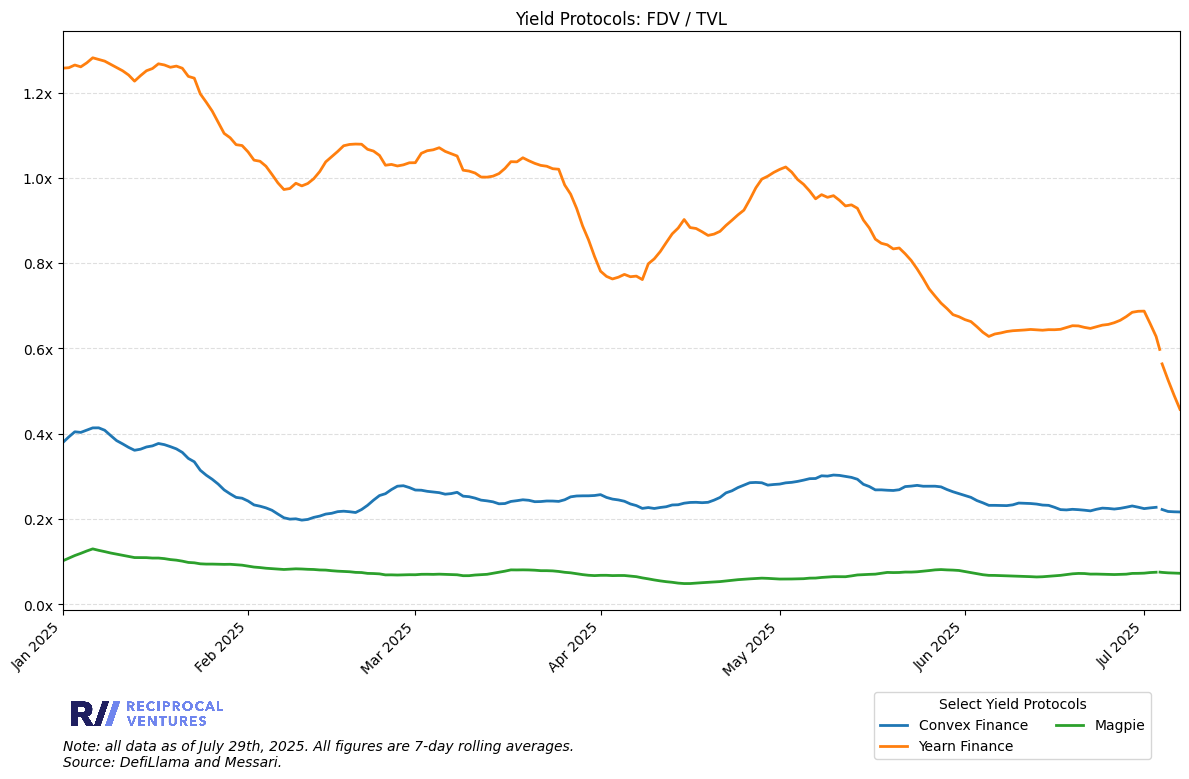

Yield Protocols FDV / TVL Statistics:
Median FDV / TVL: 0.5x
Latest Multiple: 0.3x
Mean FDV / TVL: 0.5x
80th Percentile FDV / TVL: 0.6x
20th Percentile FDV / TVL: 0.4x
Standard Deviation: 0.1x



In [5]:
# Call the function

assets = yield_protocols
breakout_asset = None
top_metric = 'FDV'
category_title = 'Yield Protocols'

tvl_yield_stats= tvl_vs_fdv_asset(
    start_date     = start_date,
    assets         = assets,
    breakout_asset = breakout_asset,
    top_metric     = top_metric,
    category_title = category_title
)

In [6]:
start_date = format_date_with_suffix(start_date)

combined_stats = pd.DataFrame({
    f'FDV / Annualized {bottom_metric}':              fee_yield_stats,
    'TVL / FDV':                tvl_yield_stats

})

combined_stats.index = [
    'Median',
    'Most Recent',
    'Mean',
    '80th Percentile',
    '20th Percentile',
    'Standard Deviation'
]

# Re-order and keep only the fields I want to display
desired_order = ['Mean', 'Standard Deviation', 'Most Recent']
filtered_stats = combined_stats.reindex(desired_order)

# Build the Styler with my centered title
title_html = f"<strong>Select {category_title}: TTM Multiples</strong>"

styled = (
    filtered_stats
      .style
      .set_caption(title_html)
      .set_table_styles([
          {"selector": "caption",
           "props": [
             ("caption-side", "top"),
             ("text-align", "center"),
             ("font-weight", "bold"),
             ("text-decoration", "underline")
           ]},
          # turn off bold for *all* index & header cells
          {"selector": ".blank, .row_heading, .col_heading",
           "props": [
             ("font-weight", "normal")
           ]},
      ], overwrite=False)
      .format(lambda v: f"{v:,.1f}x" if pd.notnull(v) else "")
)

# Render the table to an HTML string
table_html = styled.to_html()   # or .render() on older pandas

# Build my notes block
notes_html = f"""
<div style="text-align:left; margin-top:1em; font-size:0.9em">
  Notes:<br>
  • All data from {start_date} to {date}.<br>
  • Includes: Convex, Yearn, and Magpie.<br>
  • Multiples are FDV-weighted.<br>
  Sources: DefiLlama and Messari.
</div>
"""

# Combine and display as one HTML
full_html = table_html + notes_html
display(HTML(full_html))

,FDV / Annualized Fees,TVL / FDV
Mean,9.0x,0.5x
Standard Deviation,8.0x,0.1x
Most Recent,3.0x,0.3x


In [7]:
# Function to plot exchanges by a metric
def cexs_by_metric(cexs, metric, start_date, end_date):
    
    start_date_dt = pd.to_datetime(start_date)
    end_date_dt = pd.to_datetime(end_date) - pd.Timedelta(days=1)

    df_master = None
    
    for cex_id, cex_name in cexs.items():
        with open(f"raw-data/messari-raw-data/messari_{cex_id}_{metric}.json", 'r') as f:
            data = json.load(f)
        
        
        # Structure data
        points = data['data']['points']
        schemas = data['metadata']['pointSchemas']

        # Get every slug out of the metadata
        col_slugs = [s['slug'] for s in schemas]
        
        #    e.g. ['time','trade-count','volume-usd','volume-buy-usd','volume-sell-usd']
    
        # Build the DataFrame with exactly those columns
        raw_df = pd.DataFrame(points, columns=col_slugs)
    
        # Convert the timestamp column
        raw_df['date'] = pd.to_datetime(raw_df['time'], unit='s')
    
        # Pick the slug that corresponds to our metric string
        #    for 'volume' files it'll usually be literally 'volume',
        #    for 'futures-volume' it's 'volume-usd'
        matches = [slug for slug in col_slugs if metric.replace('-', '') in slug.replace('-', '')]
        if len(matches) != 1:
            raise ValueError(f"Could not unambiguously map metric={metric} to any slug in {col_slugs}")
        target_slug = matches[0]
    
        # Rename that one column to your human‐friendly CEX name
        raw_df = raw_df[['date', target_slug]].rename(columns={ target_slug: cex_name })
    
        # Appply your 7-day rolling, merge, etc.
        raw_df[cex_name] = raw_df[cex_name].rolling(window=7).mean()
        df_master = raw_df if df_master is None else df_master.merge(raw_df, on='date', how='outer')
        df_master.fillna(0, inplace=True)
    
    # Filter by appropriate dates
    df_master = df_master.loc[(df_master['date'] >= start_date_dt) &
    (df_master['date'] < end_date_dt)
    ]
        
    # Sort your master dataframe by date
    df_master = df_master.sort_values('date')

    # Fill NA w/ 0
    df_master = df_master.ffill()
    
    # Grab the last row of numbers
    last_row = df_master.iloc[-1]
    
    # Sort the cex names by descending value on that last row
    cex_list = sorted(
        cexs.values(),
        key=lambda cex_name: last_row[cex_name],
        reverse=True
    )

    
    # Prepare the values in the right order
    dates   = df_master['date']
    series  = [df_master[cex_name] for cex_name in cex_list]
    
    # Plot a single stacked‐area call
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.stackplot(
        dates,
        *series,
        labels=cex_list
    )
    
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e9:.0f}b'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45)
    ax.margins(x=0)
    
    ax.legend(loc='upper left', bbox_to_anchor=(0,1), ncol=3)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    add_logo(ax, position=(0.08, -0.17))
    ax.margins(x=0)
    plt.figtext(0.12, -0.11, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama", ha='left', fontsize=10, style='italic')
    if metric == 'volume':
        metric_styled = 'Volume'
    if metric == 'futures-volume':
        metric_styled = 'Futures Volume'
    ax.set_title(f'CEXs by Daily {metric_styled}')
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/cexs-{metric}.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(df_master.tail(5))

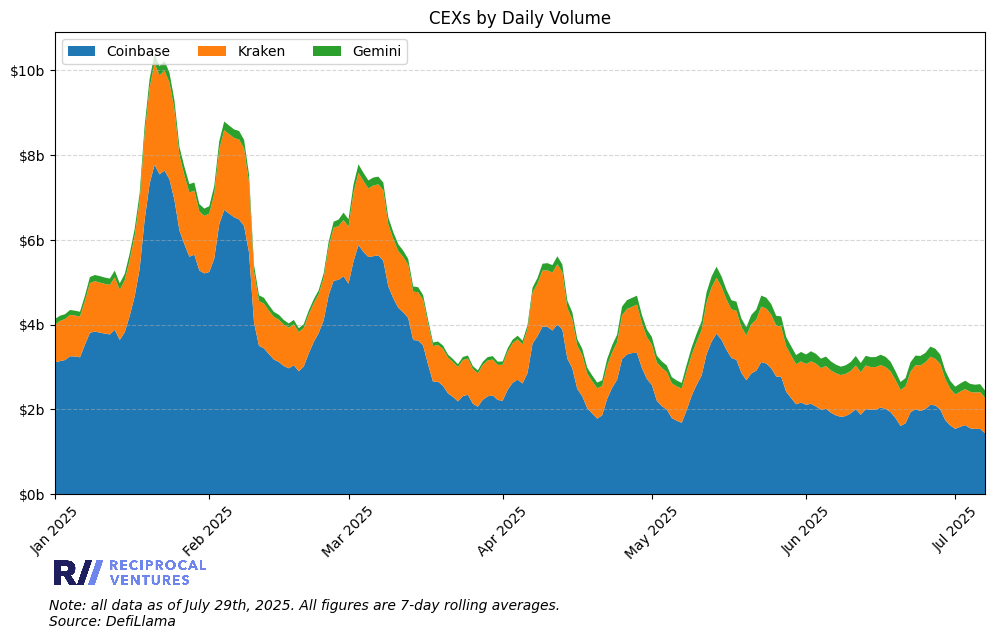

          date      Coinbase        Gemini        Kraken
244 2025-07-03  1.626381e+09  1.960495e+08  8.508979e+08
245 2025-07-04  1.550681e+09  1.878139e+08  8.603833e+08
246 2025-07-05  1.535202e+09  1.855944e+08  8.585044e+08
247 2025-07-06  1.538151e+09  1.870594e+08  8.680810e+08
248 2025-07-07  1.431847e+09  1.739498e+08  8.364155e+08


In [8]:
# Call the function
cexs = {'coinbase': 'Coinbase',
    'gemini': 'Gemini',
        'kraken': 'Kraken'
       }
metric = 'volume' # 'volume' or 'futures-volume'
start_date = '2025-01-01'
end_date = today

cexs_by_metric(cexs, metric, start_date, end_date)

['atehun', 'autist', 'catbal', 'cz-on-hyperliquid', 'ethena-usde', 'farm-2', 'hyena', 'hyperlauncher', 'hypurr-fun', 'jeff-3', 'liquina', 'ora-coin', 'pip-3', 'purr-2', 'rugman', 'sovrun', 'vapor', 'vegas', 'yeeti']


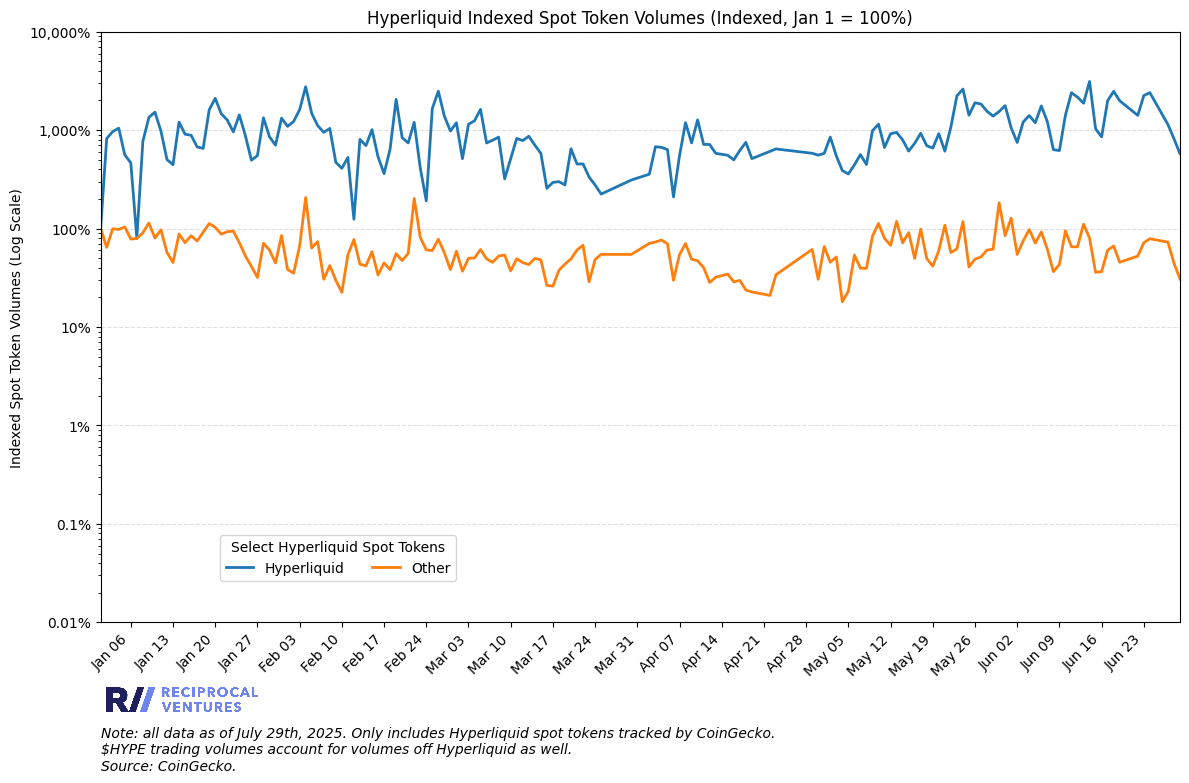

In [9]:
# Function to save down list of all token IDs on Hyperliquid

def identify_token_ids(file_path, network):
    with open(file_path, 'r') as f:
        data = json.load(f)
        
    filtered = []
    for entry in data:
        token_id = entry.get('id', [])
        platform_dict = entry.get('platforms', [])
        if network not in platform_dict:
            continue
        
        else:
            filtered.append(token_id)
    
    return filtered

file_path = 'raw-data/coingecko-raw-data/coingecko_asset-list.json'
network = 'hyperliquid'

assets = identify_token_ids(file_path, network)

df_master = None

for asset in assets:
    try:
        # Load data spot asset data
        path = f"raw-data/coingecko-raw-data/coingecko_{asset}_spot_strict_list_data.json"
        with open(path) as f:
            data = json.load(f)
    
        coin_df = (
            pd.DataFrame(data["total_volumes"], columns=["timestamp", asset])
              .assign(date=lambda d: pd.to_datetime(d["timestamp"], unit="ms"))
              .loc[:, ["date", asset]]
        )

        # Make sure the coin traded on the start date
        start_date = '2025-01-01'
        coin_df = coin_df[coin_df['date'] >= start_date]
        
        first_date = coin_df['date'].iloc[0].strftime("%Y-%m-%d")
        if first_date != start_date:
            continue
        
        # Merge dataframes
        df_master = coin_df if df_master is None else df_master.merge(coin_df, on="date", how="inner")
        df_master = df_master.sort_values("date").reset_index(drop=True)
    except:
        continue

# seperate breakout assets from other assets
keep_list = []
breakout_assets = {'hyperliquid': 'Hyperliquid'
                  }
for key, value in breakout_assets.items():
    df_master.rename(columns={key: value}, inplace = True)
    keep_list.append(value)
other_assets = [c for c in df_master.columns if c not in breakout_assets.values() and c != 'date']
print(other_assets)
df_master['Other'] = df_master[other_assets].sum(axis=1)
keep_list.append('Other')

final_columns = ['date'] + keep_list

df_master = df_master[final_columns]

# Transform into an index
for asset in keep_list:
    first_volume = df_master[asset].iloc[0]
    df_master[asset] = df_master[asset] / first_volume * 100

# Create the line chart
fig, ax = plt.subplots(figsize=(12, 8))

# Plotting the line chart
for asset in keep_list:
        ax.plot(
        df_master['date'], 
        df_master[asset], 
        label=asset,
        linewidth=2
        )

# Setting labels and title
ax.set_title('Hyperliquid Indexed Spot Token Volumes (Indexed, Jan 1 = 100%)')
ax.set_ylabel('Indexed Spot Token Volumes (Log Scale)')
ax.margins(x=0)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Set y-axis to logarithmic scale
ax.set_yscale('log')

# Apply a percentage formatter to the y-axis
def format_y(x, _):
    """Integers for values ≥ 1, variable decimals for values < 1."""
    if x >= 1:
        return f"{x:,.0f}%" # e.g. 2 000
    # format to 10 dp then strip trailing zeros/decimal point
    return f"{x:.10f}".rstrip("0").rstrip(".")+"%"

ax.yaxis.set_major_formatter(mtick.FuncFormatter(format_y))

# Set y-axis limits with lower bound as 10 (10^1)
ax.set_ylim(0.01, 10000)

# Add grid lines for better readability
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Add logo
add_logo(ax, position=(0.075, -0.13))

# Add sources and note
text_box = ax.text(0, -0.25, f"Note: all data as of {date}. Only includes Hyperliquid spot tokens tracked by CoinGecko.\n$HYPE trading volumes account for volumes off Hyperliquid as well.\nSource: CoinGecko.",
                   ha='left', transform=ax.transAxes, fontsize=10,
                   bbox=dict(facecolor='white', alpha=0), fontstyle='italic')

# Center the legend below the chart
plt.legend(title='Select Hyperliquid Spot Tokens', bbox_to_anchor=(0.22, 0.16), loc='upper center', ncol=4)

# Ensure the layout adapts to fit all elements (legend, text, etc.)
plt.tight_layout()

# Save plot
if not os.path.exists("plots"):
    os.makedirs("plots")
plt.savefig(f"{plots_filepath}/hyperliquid-indexed-spot-token-volumes.png", dpi=300, bbox_inches='tight')

# Show
plt.show()

In [10]:
# Function plot fees or revenue for any projects as a timeseries
def fees_or_revenue_timeseries(metric, assets, start_date, end_date):
    
    asset_colors = ['#1f1f60',
                    '#4A5DB2',
                    '#494949',
                    '#A0A0A0'
                   ]
    
    metric_identifier = 'Revenue'
    if metric == 'dailyFees':
        metric_identifier = 'Fees'
    
    df_master = None

    start_date_dt = pd.to_datetime(start_date)
    end_date_dt = pd.to_datetime(end_date) - pd.Timedelta(days=1)
    
    for asset_slug, asset_name in assets.items():
        with open(f'raw-data/defillama-raw-data/{metric}_data/{asset_slug}_{metric_identifier}.json') as f:
            data = json.load(f)
        
        # Select only the two real keys, then rename
        raw_df = pd.DataFrame(
            data['totalDataChart'],
            columns=['date', asset_name]
        )
        raw_df.rename(columns={
            'date': 'timestamp',
            f'{metric}': asset_name
        }, inplace=True)
        raw_df['date'] = pd.to_datetime(raw_df['timestamp'], unit='s')
        raw_df = raw_df[['date', asset_name]]
        raw_df[asset_name] = raw_df[asset_name].rolling(window=7).mean()
    
        # Merge dataframes
        df_master = raw_df if df_master is None else df_master.merge(raw_df, on='date', how='outer')
        df_master = df_master.ffill()

    # Filter by appropriate dates
    df_master = df_master.loc[(df_master['date'] >= start_date_dt) &
    (df_master['date'] < end_date_dt)
    ]
    
    # Sort your master dataframe by date
    df_master = df_master.sort_values('date')
    
    # Grab the last row of numbers
    last_row = df_master.iloc[-1]

    # Grab asset names
    assets = df_master.columns[1:].tolist()

    # Prepare the values and colors in the right order
    dates   = df_master['date']
    series  = [df_master[asset] for asset in assets]
    colors = asset_colors[:len(assets)]
    
    # Plot a single stacked‐area call
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.stackplot(
        dates,
        *series,
        labels=assets,
        colors=colors
    )
    
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.2f}m'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=45)
    
    ax.legend(loc='upper left', bbox_to_anchor=(0,1), ncol=2)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    add_logo(ax, position=(0.08, -0.17))
    ax.margins(x=0)
    plt.figtext(0.12, -0.11, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama", ha='left', fontsize=10, style='italic')
    if metric == 'dailyFees':
        ax.set_title(f'Daily Fees by Protocol')
    if metric == 'dailyRevenue':
        ax.set_title(f'Daily Revenue by Protocol')
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/breakout-{metric}-timeseries.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(df_master.tail(5))

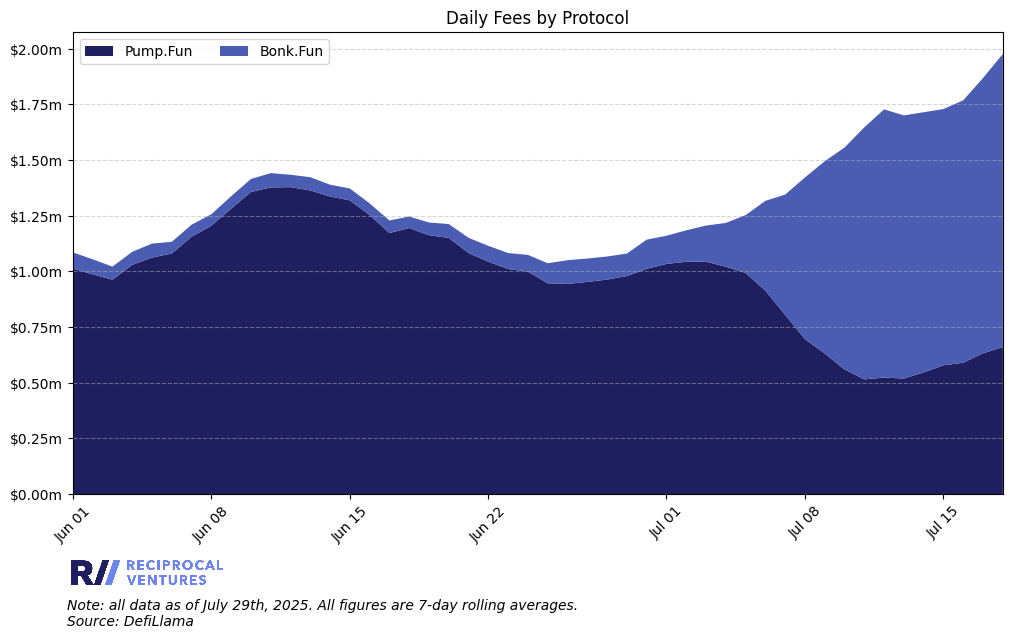

          date       Pump.Fun      Bonk.Fun
499 2025-07-14  546488.714286  1.168696e+06
500 2025-07-15  578162.857143  1.151276e+06
501 2025-07-16  589869.142857  1.179010e+06
502 2025-07-17  632331.000000  1.236674e+06
503 2025-07-18  660054.857143  1.316726e+06


In [11]:
# Call the function
metric = 'dailyFees' # 'dailyFees' or 'dailyRevenue'
start_date = '2025-06-01'
end_date = today
assets = {'pumpfun': 'Pump.Fun',
                    'bonkfun': 'Bonk.Fun',
             }

fees_or_revenue_timeseries(metric, assets, start_date, end_date)

In [14]:
# Function for plotting tvl / mcap or fdv charts for a set of assets

def plot_mcap_to_annualized_revenue_multiple(start_date, ticker):
    
    # Load mcap / annualized revenue multiple
    path = f"raw-data/yahoofinance-raw-data/{ticker}_mcap_to_annualized_rev.json"
    with open(path) as f:
        data = json.load(f)

    df = (
    pd.DataFrame.from_dict(data, orient='index')   # rows keyed by date‑string
      .reset_index()
      .rename(columns={'index':'date'})
    )
    
    # Parse the date column
    df['date'] = pd.to_datetime(df['date'])
    
    # Keep only the rev column and filter
    df = df[['date', f'{ticker}_mcap_to_annualized_total_rev']]
    df[f'{ticker}_mcap_to_annualized_total_rev'] = df[f'{ticker}_mcap_to_annualized_total_rev'].rolling(window=7, min_periods=1).mean()
    df = df[df['date'] >= pd.to_datetime(start_date)]
    
    # Merge asset dataframe into the master dataframe
    df_master = df

    # Cut off df_master to only be after start date
    df_master = df_master[df_master['date'] >= start_date]
    
    # Create the line chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plotting the line chart with custom colors
    ax.plot(
        df_master['date'], 
        df_master[f'{ticker}_mcap_to_annualized_total_rev'], 
        label=ticker, 
        linewidth=2
    )
    
    # Setting labels and title
    ax.set_title(f'{ticker}: MCAP / Annualized Revenue')
    ax.margins(x=0)
    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.1f}x'))

    # Add grid lines for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add logo
    add_logo(ax, position=(0.075, -0.18))

    date = format_date_with_suffix(today)
    
    # Add sources and note
    text_box = ax.text(0, -0.27, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: Yahoo Finance.",
                       ha='left', transform=ax.transAxes, fontsize=10,
                       bbox=dict(facecolor='white', alpha=0), fontstyle='italic')
    
    # Ensure the layout adapts to fit all elements (legend, text, etc.)
    plt.tight_layout()
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/{ticker} mcap to annualized revenue multiple.png", dpi=300, bbox_inches='tight')
    
    # Show
    plt.show()
    
    # Calculate statistical percentiles for multiple
    median = df_master[f"{ticker}_mcap_to_annualized_total_rev"].median()
    latest_multiple = df_master[f"{ticker}_mcap_to_annualized_total_rev"].dropna().iloc[-1]
    mean = df_master[f"{ticker}_mcap_to_annualized_total_rev"].mean()
    percentile_80 = df_master[f"{ticker}_mcap_to_annualized_total_rev"].quantile(0.80)
    percentile_20 = df_master[f"{ticker}_mcap_to_annualized_total_rev"].quantile(0.20)
    stdev = df_master[f"{ticker}_mcap_to_annualized_total_rev"].std()
    

    stats = {
        "median_multiple": median,
        'latest_multiple': latest_multiple,
        'mean_multiple': mean,
        "80th_percentile_multiple": percentile_80,
        "20th_percentile_multiple": percentile_20,
        'stdev_multiple': stdev
    }
    
    # Print results in human-readable format
    print(f"MCAP / Annualized Revenue Statistics:")
    print(f"Median: {median:,.1f}x")
    print(f"Latest Multiple: {latest_multiple:,.1f}x")
    print(f"Mean: {mean:,.1f}x")
    print(f"80th Percentile: {percentile_80:,.1f}x")
    print(f"20th Percentile: {percentile_20:,.1f}x")
    print(f'Standard Deviation: {stdev:,.1f}x')
    print()

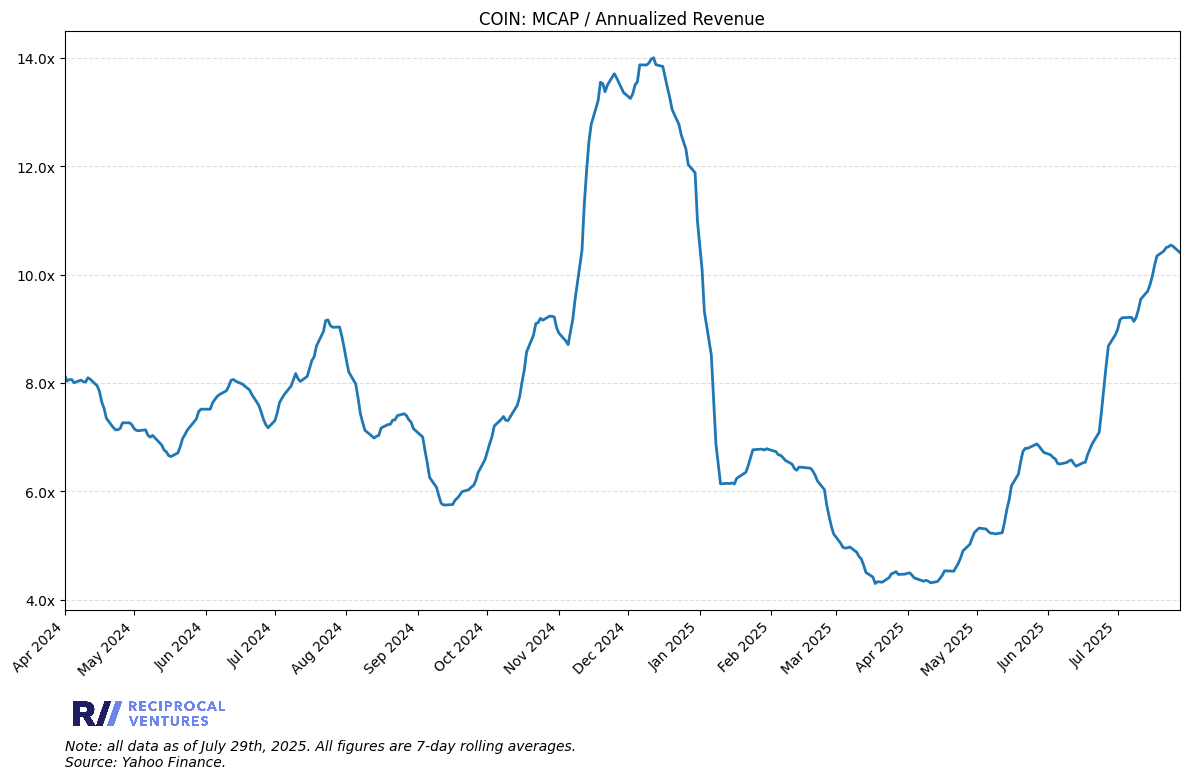

MCAP / Annualized Revenue Statistics:
Median: 7.2x
Latest Multiple: 10.4x
Mean: 7.7x
80th Percentile: 9.1x
20th Percentile: 6.0x
Standard Deviation: 2.3x



In [16]:
# Call the function
tickers   = 'COIN'
start_date = "2020-01-01"

plot_mcap_to_annualized_revenue_multiple(start_date, tickers)

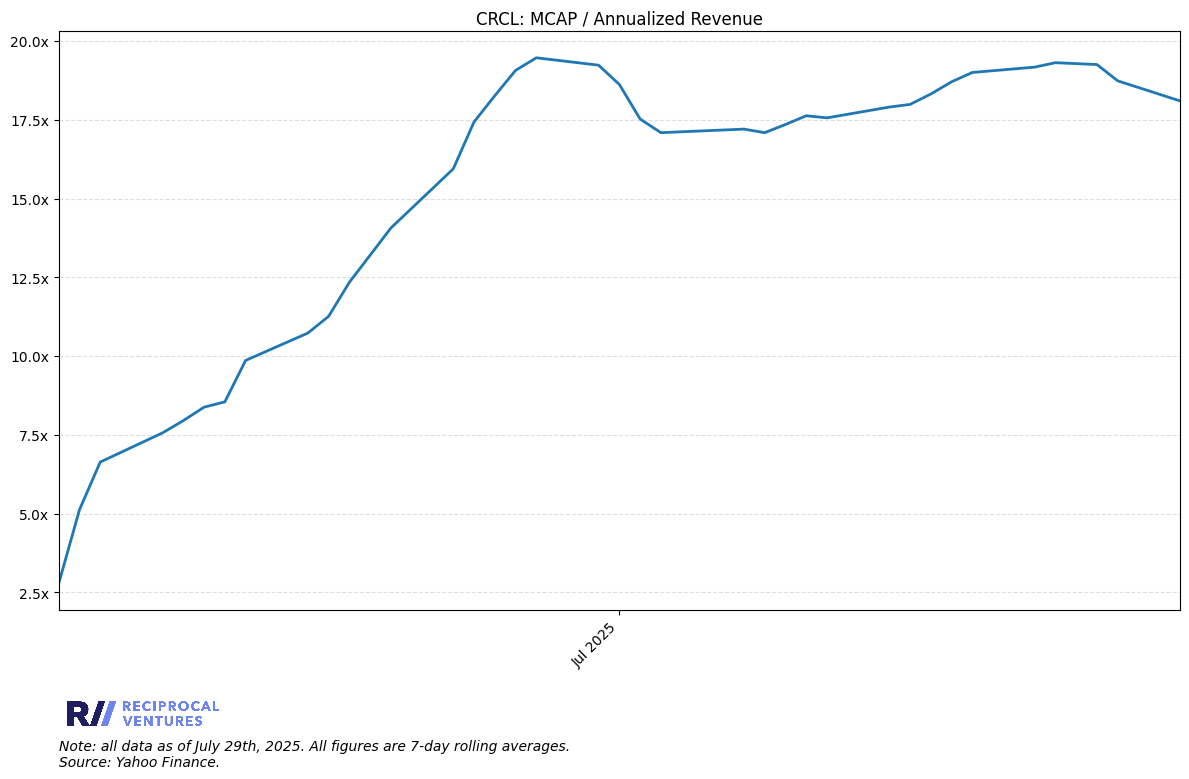

MCAP / Annualized Revenue Statistics:
Median: 17.5x
Latest Multiple: 18.1x
Mean: 15.1x
80th Percentile: 18.9x
20th Percentile: 10.0x
Standard Deviation: 4.9x



In [17]:
# Call the function
tickers   = 'CRCL'
start_date = "2020-01-01"

plot_mcap_to_annualized_revenue_multiple(start_date, tickers)